<a href="https://colab.research.google.com/github/vicky5859/computer-vison-/blob/main/EX%3A14%20Perform%20transformation%20using%20Homography%20matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-08-05 131229.png to Screenshot 2026-08-05 131229.png
Homography Matrix:
[[ 3.99452586e-01 -1.59744409e-01  5.00000000e+01]
 [-1.80505415e-01  3.31802455e-01  5.00000000e+01]
 [-3.51917288e-04 -1.33296824e-03  1.00000000e+00]]


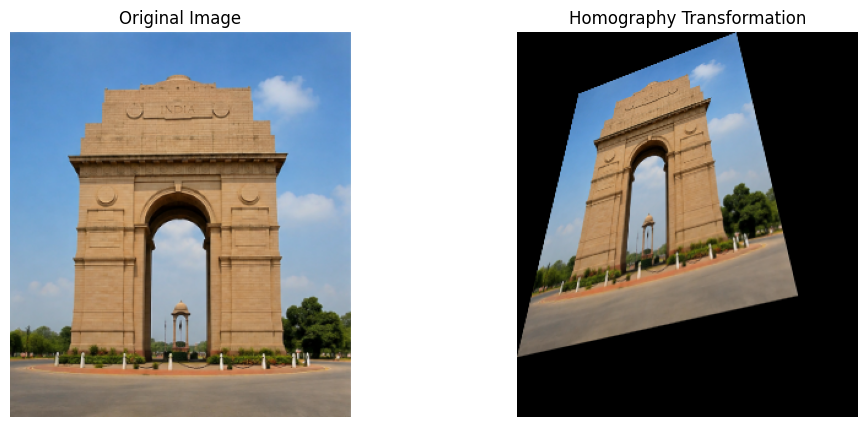

In [1]:
# EXPERIMENT 14
# Transformation using Homography Matrix

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image
img = cv2.imread(filename)

if img is None:
    print("Error: Image not found")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    # Source points
    src_pts = np.float32([
        [0, 0],
        [w - 1, 0],
        [w - 1, h - 1],
        [0, h - 1]
    ])

    # Destination points
    dst_pts = np.float32([
        [50, 50],
        [w - 100, 0],
        [w - 50, h - 100],
        [0, h - 50]
    ])

    # Calculate Homography Matrix
    H, status = cv2.findHomography(src_pts, dst_pts)

    print("Homography Matrix:")
    print(H)

    # Apply transformation
    result = cv2.warpPerspective(img, H, (w, h))

    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    # Display
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(result_rgb)
    plt.title("Homography Transformation")
    plt.axis("off")

    plt.show()